####  ETL 

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns  
import matplotlib.pyplot as plt 

data loading

In [2]:
df=pd.read_csv("Ecommerce_Sales_Data_2024_2025.csv")

data overview

In [3]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [4]:
df.shape

(5000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   str    
 2   Customer Name  5000 non-null   str    
 3   Region         5000 non-null   str    
 4   City           5000 non-null   str    
 5   Category       5000 non-null   str    
 6   Sub-Category   5000 non-null   str    
 7   Product Name   5000 non-null   str    
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   str    
dtypes: float64(2), int64(4), str(8)
memory usage: 899.8 KB


Duplicate Records Check

In [6]:
df.duplicated().sum()

np.int64(0)

missing value check 

In [7]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

column name cleaning 

In [8]:
df.columns =df.columns.str.strip()

In [9]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='str')

date formate conversion 

In [11]:
df["Order Date"] =pd.to_datetime(df["Order Date"],errors="coerce")

In [12]:
df["Order Date"].dtype

dtype('<M8[us]')

text data cleaning 

In [13]:
columns_text = [
    'Customer Name',
    'Region',
    'City',
    'Category',
    'Sub-Category',
    'Product Name',
    'Payment Mode'
]

for col  in columns_text:
    df[col] =df[col].str.strip()

Numerical Data Validation

In [14]:
df[['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit']].describe()

,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,1.000000,222.000000,0.000000,264.100000,19.120000
25%,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,5.000000,79998.000000,20.000000,398485.000000,89688.440000


Final ETL Validation

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[us]
 2   Customer Name  5000 non-null   str           
 3   Region         5000 non-null   str           
 4   City           5000 non-null   str           
 5   Category       5000 non-null   str           
 6   Sub-Category   5000 non-null   str           
 7   Product Name   5000 non-null   str           
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   int64         
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
 13  Payment Mode   5000 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(4), str(7)
memory usage: 855.2 KB


In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum().sum()

np.int64(0)

In [21]:
df.shape

(5000, 14)

Load — Export Cleaned Dataset


In [20]:
df.to_csv(
    "Ecommerce_sales_clean.csv",
    index=False
)

# Exploratory Data Analysis (EDA)

## Product Performance Analysis

product wise sales analysis

In [22]:
product_sales  =(
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
product_sales.head(10)

Product Name
Headphones Accusantium     857184.20
Spices Quibusdam           687651.25
Accessories Repellendus    687083.30
Bed Tenetur                670994.80
Laptop Similique           666640.60
Lamp Enim                  665920.20
Shampoo Commodi            659546.60
Lamp Veritatis             652909.50
Men's Wear Voluptatibus    649048.00
Textbook Omnis             633246.25
Name: Sales, dtype: float64

top 10 product by sales chart

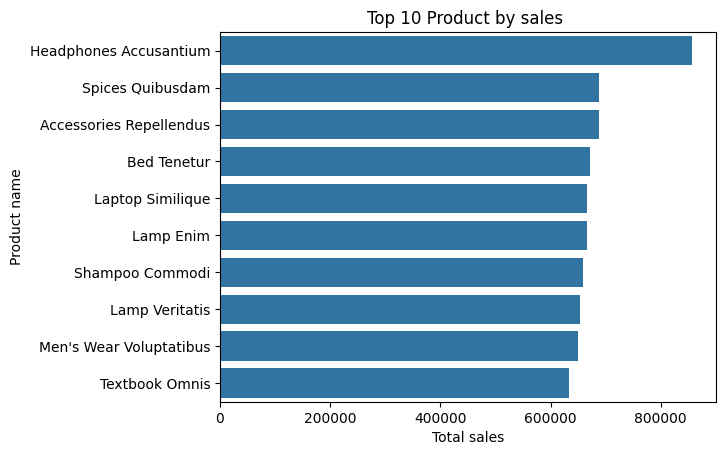

In [24]:
top_10_product =product_sales.head(10)
plt.Figure(figsize=(10,6))
sns.barplot(
    x=top_10_product.values,
    y=top_10_product.index
)
plt.title("Top 10 Product by sales ")
plt.xlabel("Total sales")
plt.ylabel("Product name")
plt.show()

Product-wise Quantity Analysis

In [25]:
product_quantity =(
    df.groupby("Product Name")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)
product_quantity.head(10)

Product Name
Microwave Provident    17
Lamp Enim              16
Board Game Ab          15
Lamp Nostrum           15
Women's Wear Optio     15
Kids Wear Accusamus    15
Oil Iusto              14
Textbook Omnis         14
Comics Voluptatibus    14
Puzzle Illo            14
Name: Quantity, dtype: int64

 Top 10 Products by Quantity Sold

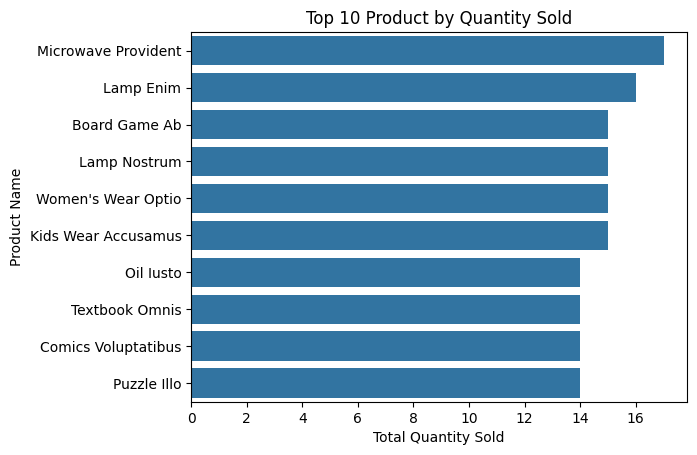

In [31]:
top_10_product_quantity=product_quantity.head(10)
plt.Figure(figsize=(10,6))
sns.barplot(
    x=top_10_product_quantity.values,
    y=top_10_product_quantity.index
)
plt.title("Top 10 Product by Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product Name")
plt.show()

Product-wise Profit Analysis


In [32]:
product_profit=(
    df.groupby("Product Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)
product_profit.head(10)

Product Name
Headphones Accusantium     141873.79
Laptop Similique           136751.80
Accessories Repellendus    131526.41
Textbook Omnis             119166.66
Lipstick Accusamus         119017.65
Men's Wear Voluptatibus    118300.59
Shampoo Commodi            111950.64
Cushion Rem                111530.63
Wall Art Saepe             109548.98
Sugar Voluptates           108494.16
Name: Profit, dtype: float64

Top 10 Products by Profit

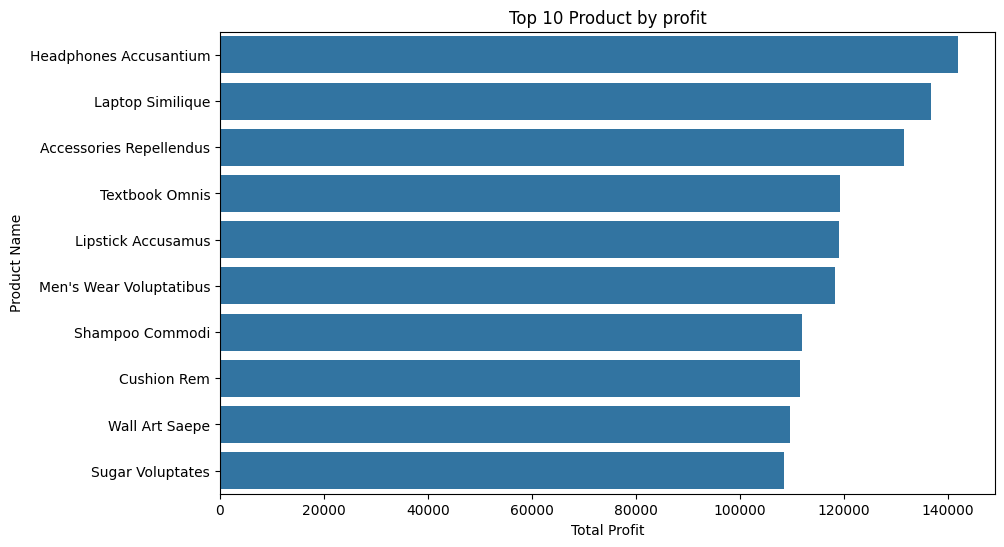

In [36]:
top_10_product_profit = product_profit.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_10_product_profit.values,
    y=top_10_product_profit.index
)
plt.title("Top 10 Product by profit")
plt.xlabel("Total Profit")
plt.ylabel("Product Name")
plt.show()

 Product Sales vs Profit Analysis

In [39]:
product_performance  =(
    df.groupby('Product Name')[['Sales', 'Profit']]
    .sum()
    .sort_values("Sales" , ascending=False)
)
product_performance.head(10)

,Sales,Profit
Product Name,,
Headphones Accusantium,857184.20,141873.79
Spices Quibusdam,687651.25,96587.33
Accessories Repellendus,687083.30,131526.41
Bed Tenetur,670994.80,100233.59
Laptop Similique,666640.60,136751.80
Lamp Enim,665920.20,93638.94
Shampoo Commodi,659546.60,111950.64
Lamp Veritatis,652909.50,62922.96
Men's Wear Voluptatibus,649048.00,118300.59


Sales vs Profit by Product chart

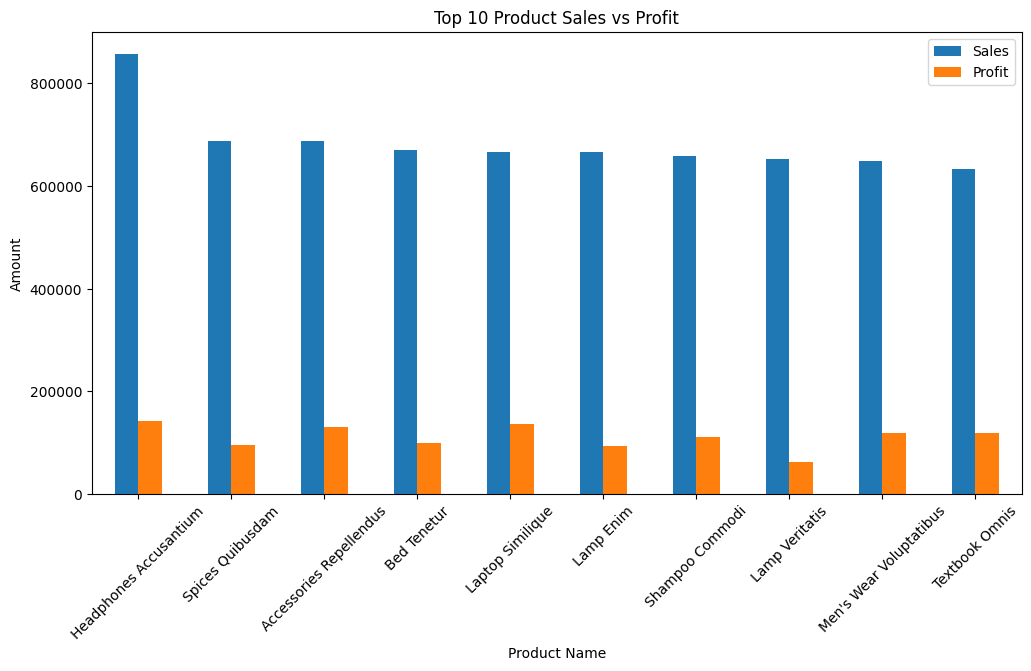

In [40]:
top_product_performance =product_performance.head(10)
top_product_performance.plot(
    kind="bar",
    figsize=(12,6)
)
plt.title("Top 10 Product Sales vs Profit")
plt.xlabel("Product Name")
plt.ylabel("Amount")
plt.xticks(rotation = 45)
plt.legend(["Sales","Profit"])
plt.show()

 Product Profit Margin Analysis

Profit Margin (%) = (Total Profit / Total Sales) × 100

In [41]:
product_margin = (
    df.groupby('Product Name')[['Sales', 'Profit']]
      .sum()
)

product_margin['Profit Margin %'] = (
    product_margin['Profit'] /
    product_margin['Sales']
) * 100

product_margin = product_margin.sort_values(
    'Profit Margin %',
    ascending=False
)

product_margin.head(10)

,Sales,Profit,Profit Margin %
Product Name,,,
Dumbbells Doloribus,127264.50,31811.06,24.996020
Microwave Nihil,153229.45,38275.00,24.978880
Smartwatch Accusantium,82840.80,20691.97,24.977994
Table Deleniti,26813.60,6696.42,24.973968
Shampoo Hic,5647.20,1409.46,24.958564
Biography Repudiandae,46017.00,11480.17,24.947672
Microwave Odio,13572.00,3385.77,24.946729
Kids Wear Labore,184247.70,45928.61,24.927644
Sugar Ab,65347.15,16285.20,24.921056


Top 10 Product by profit margin

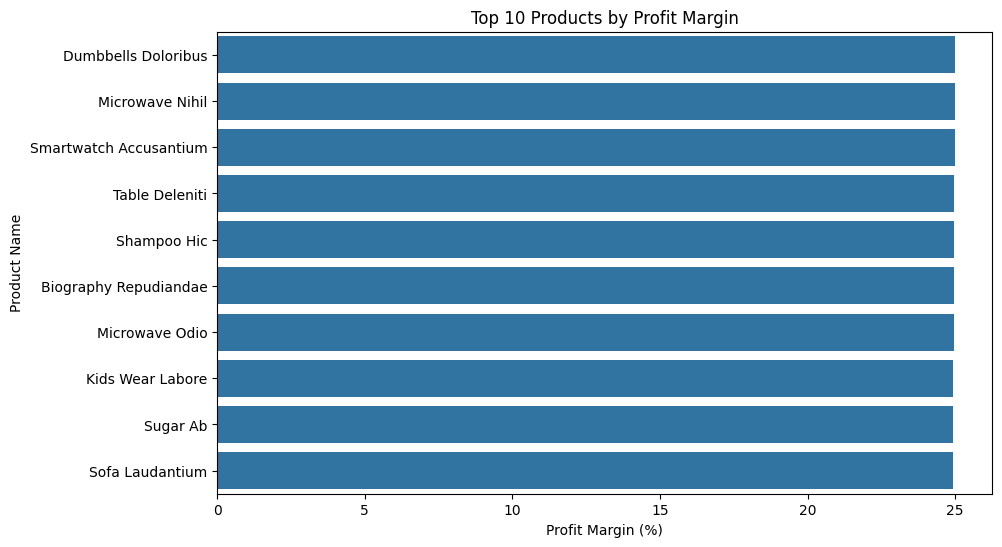

In [43]:
top_10_margin = product_margin.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_margin['Profit Margin %'],
    y=top_10_margin.index
)

plt.title('Top 10 Products by Profit Margin')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Product Name')

plt.show()

Product Profit Margin Segmentation

In [46]:
margin_75 =product_margin["Profit Margin %"].quantile(0.75)
margin_25 =product_margin["Profit Margin %"].quantile(0.25)
product_margin["Margin Level"] =np.select(
    [
        product_margin["Profit Margin %"]>=margin_75,
        product_margin["Profit Margin %"] >=margin_25
    ],
    [
        "High Margin",
        "Low Margin"
    ],
    default="Medium Margin"
)

In [48]:
product_margin["Margin Level"].value_counts()

Margin Level
Low Margin       1917
High Margin       959
Medium Margin     959
Name: count, dtype: int64

Product Margin Level Distribution

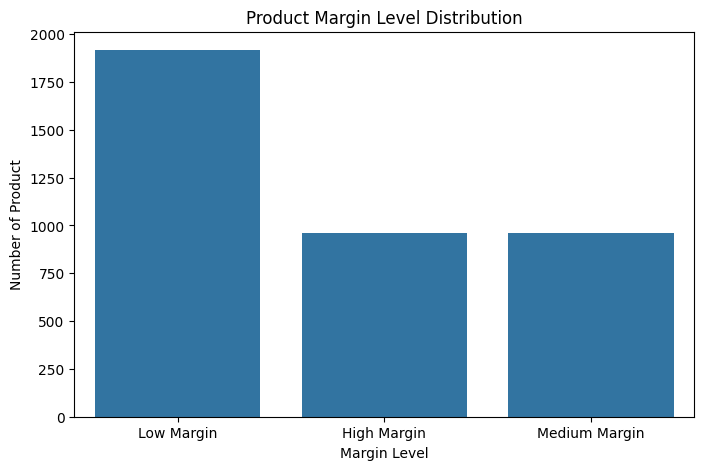

In [49]:
margin_distribution =product_margin["Margin Level"].value_counts()
plt.figure(figsize=(8,5))
sns.barplot(
    x=margin_distribution.index,
    y=margin_distribution.values
)
plt.title("Product Margin Level Distribution")
plt.xlabel("Margin Level")
plt.ylabel("Number of Product")
plt.show()

Product-wise Average Discount Analysis

In [50]:
product_discount =(
    df.groupby("Product Name")["Discount"]
    .mean()
    .sort_values(ascending=False)
)
product_discount.head(10)

Product Name
Yoga Mat Sed                 20.0
Yoga Mat Incidunt            20.0
Accessories Fuga             20.0
Accessories Facilis          20.0
Yoga Mat Est                 20.0
Yoga Mat Dolorum             20.0
Yoga Mat Dolore              20.0
Yoga Mat Adipisci            20.0
Women's Wear Voluptatum      20.0
Women's Wear Voluptatibus    20.0
Name: Discount, dtype: float64

Top 10 Products by Average Discount


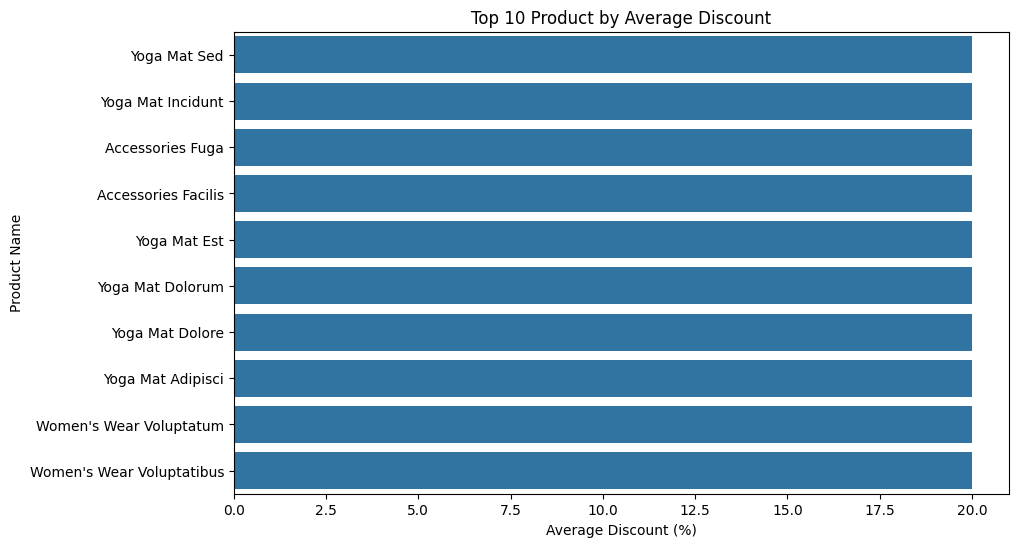

In [51]:
top_10_discount =product_discount.head(10)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_10_discount.values,
    y=top_10_discount.index
)
plt.title("Top 10 Product by Average Discount")
plt.xlabel("Average Discount (%)")
plt.ylabel("Product Name")
plt.show()

## Product Performance Analysis — Summary

The Product Performance analysis evaluated product-level Sales, Quantity, Profit, Profit Margin, and Discount.

- Headphones Accusantium generated the highest total sales of 857,184.20.
- Microwave Provident had the highest quantity sold with 17 units.
- Headphones Accusantium generated the highest total profit of 141,873.79.
- Dumbbells Doloribus recorded the highest profit margin of approximately 25%.
- Product margin segmentation was performed using NumPy.
- The analysis also identified products with higher average discounts.

Overall, the analysis helped identify the best-performing products in terms of revenue, sales volume, profitability, and profit margin.